In [2]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt
from collections import defaultdict

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 10, 15, 20, 25, 30]
windowsize = 150
L = 100

processed_regions = {}

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = [x + 1 for x in regions[region_name].modifications]

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0
    
modified_regions = list(filter(filter_entry, map(map_entry, file)))

num_modified_regions = len(modified_regions)

local_sequence_size = (4 * windowsize) - 1

accumulated_diff_data = {}

for footprint in footprints:
    f_data = {}
    for looptype in looptypes:
        f_data[looptype] = [0.0 for x in range(local_sequence_size - footprint + 2)]
    accumulated_diff_data[footprint] = f_data

print(num_modified_regions)
total_mods = 0
for region_name, sequence, modifications in modified_regions:
    for i in range(len(modifications)):
        if i > 0 and (modifications[i] - modifications[i - 1]) < 2 * windowsize:
            continue
        if i < (len(modifications) - 2) and (modifications[i + 1] - modifications[i]) < 2 * windowsize:
            continue

        modification = modifications[i]
        
        start = modification - 2 * windowsize

        if start < 0:
            continue

        end = modification + 2 * windowsize - 1

        if end > len(sequence):
            continue

        local_sequence = str(sequence[start:end])
        local_modification = modification - start

        if (local_sequence, local_modification) in processed_regions:
            continue

        processed_regions[(local_sequence, local_modification)] = True

        local_modification = [local_modification]
        
        local_data_unmod = accessibility(local_sequence, footprints, windowsize = windowsize, L = L)
        local_data = accessibility(local_sequence, footprints, windowsize = windowsize, L = L, m6A_sites = local_modification)

        for footprint in footprints:
            for looptype in local_data[footprint]:
                diff = [v for v in map(lambda pair: pair[1] - pair[0], zip(local_data[footprint][looptype], local_data_unmod[footprint][looptype]))]

                for i in range(len(diff)):
                    diff_value = diff[i]

                    accumulated_diff_data[footprint][looptype][i] += diff_value
        
        total_mods += 1

print(total_mods)


5162
378


In [4]:
average_diff_data = {}

for footprint in accumulated_diff_data:
    avg_f_data = {}
    for looptype in accumulated_diff_data[footprint]:
        avg_f_data[looptype] = [x / total_mods for x in accumulated_diff_data[footprint][looptype]]
    average_diff_data[footprint] = avg_f_data

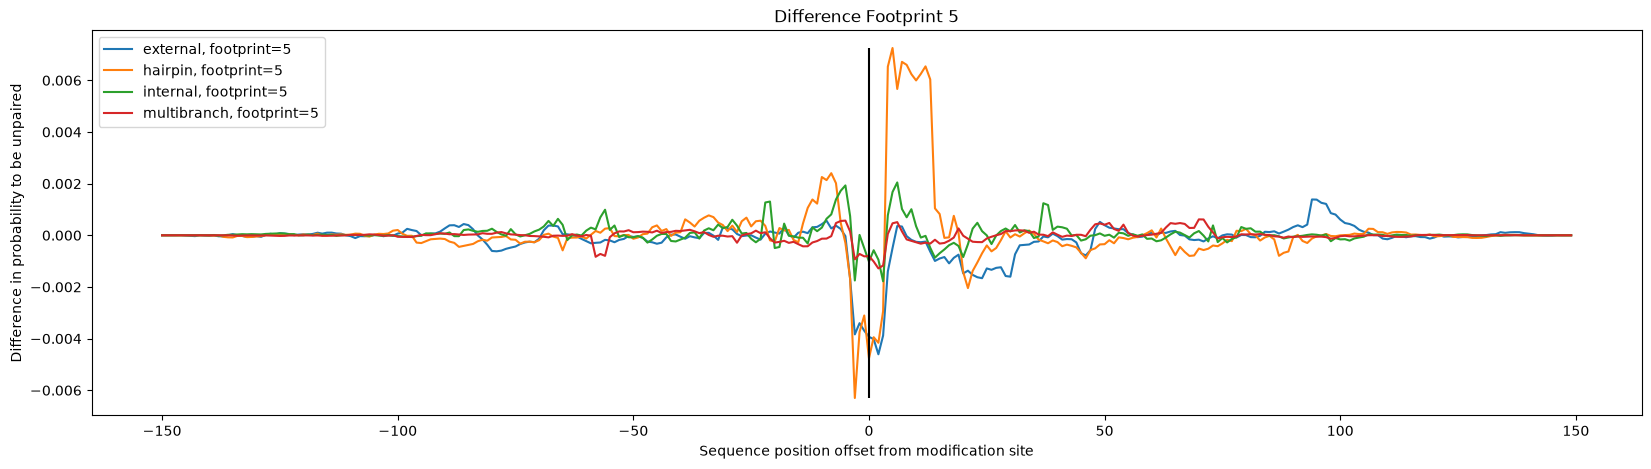

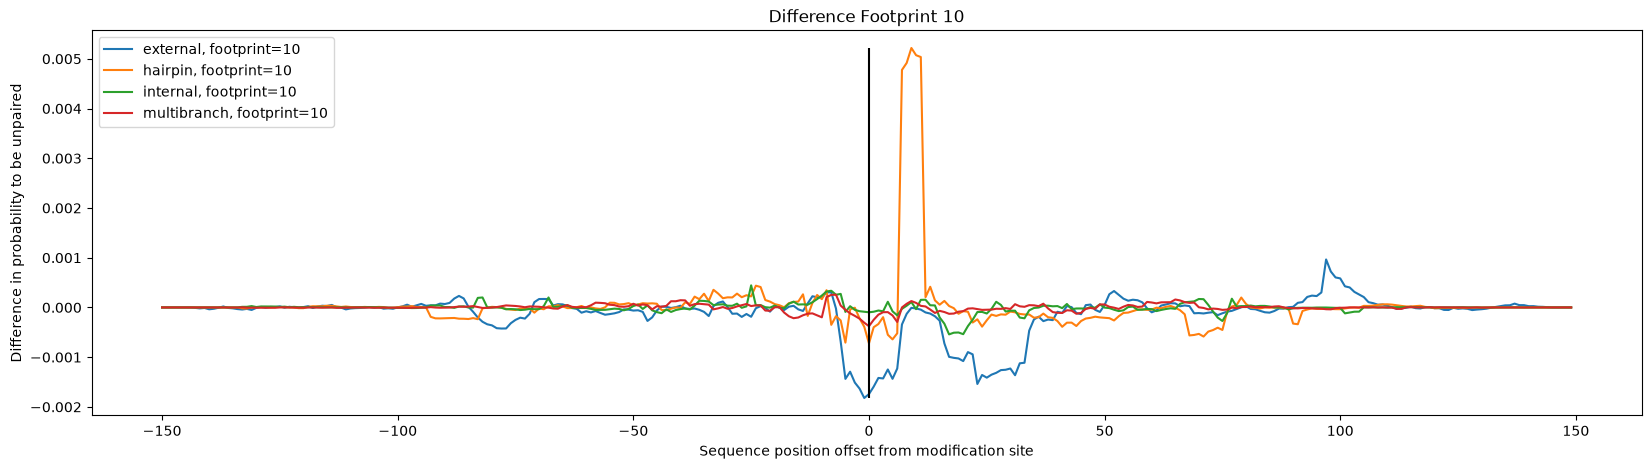

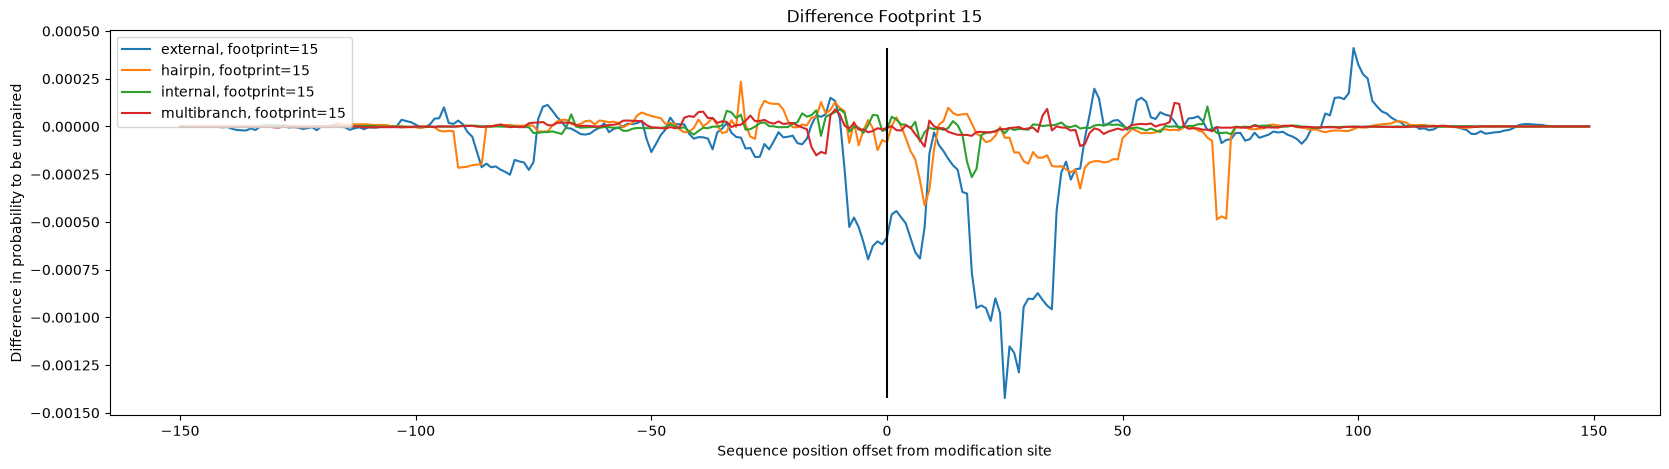

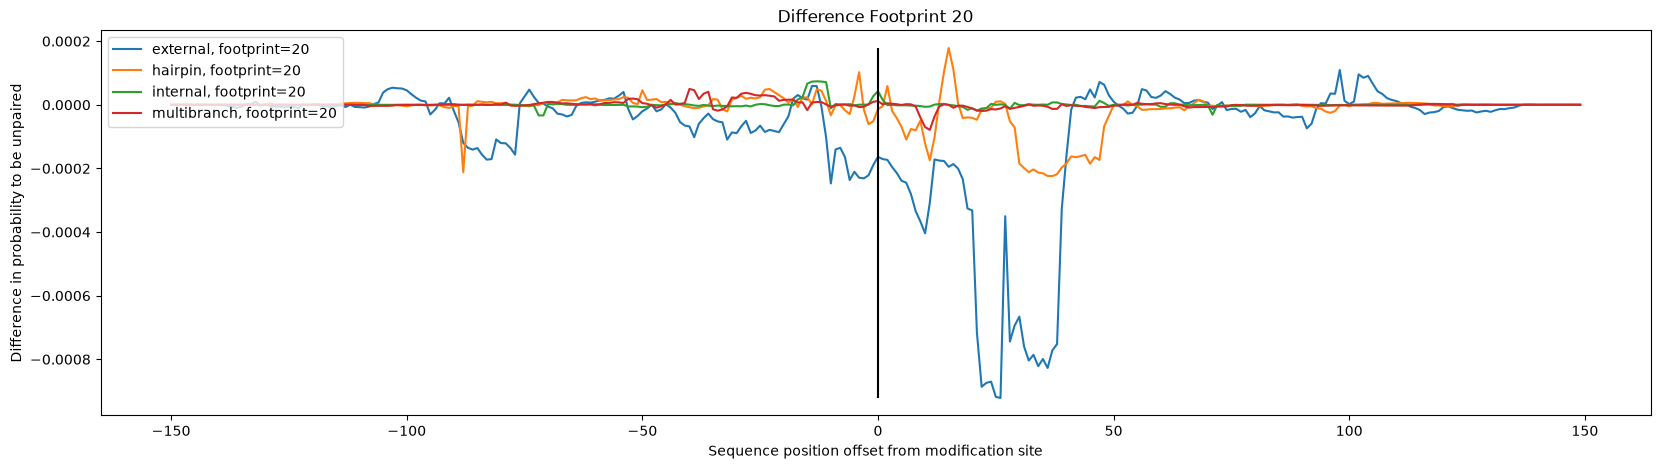

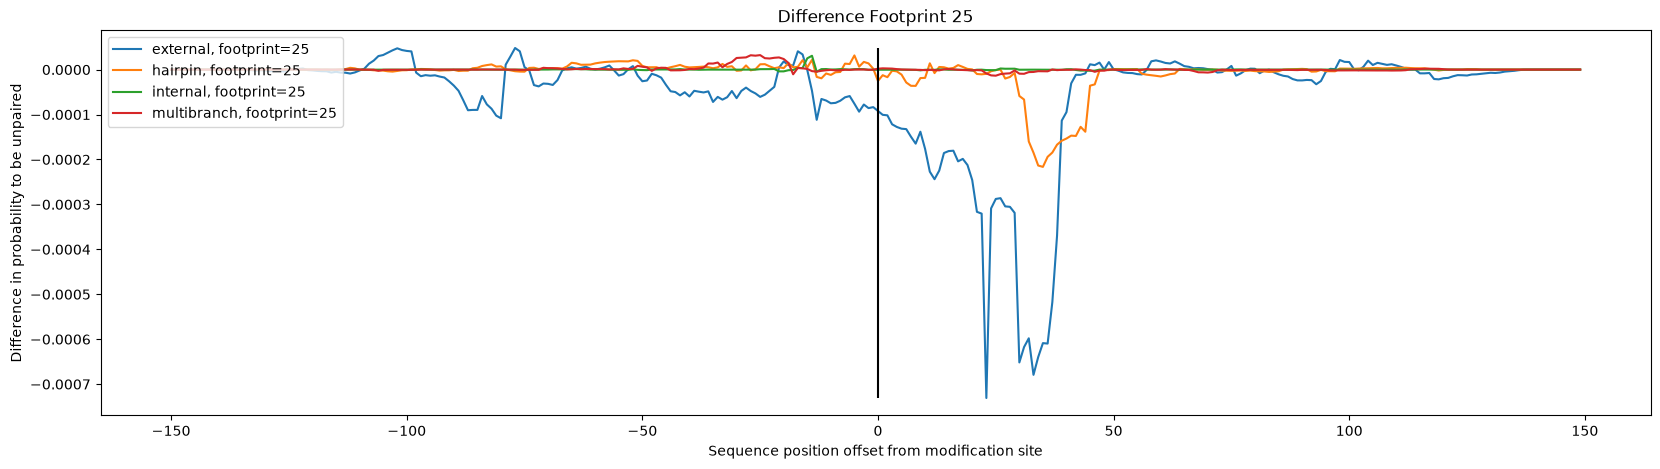

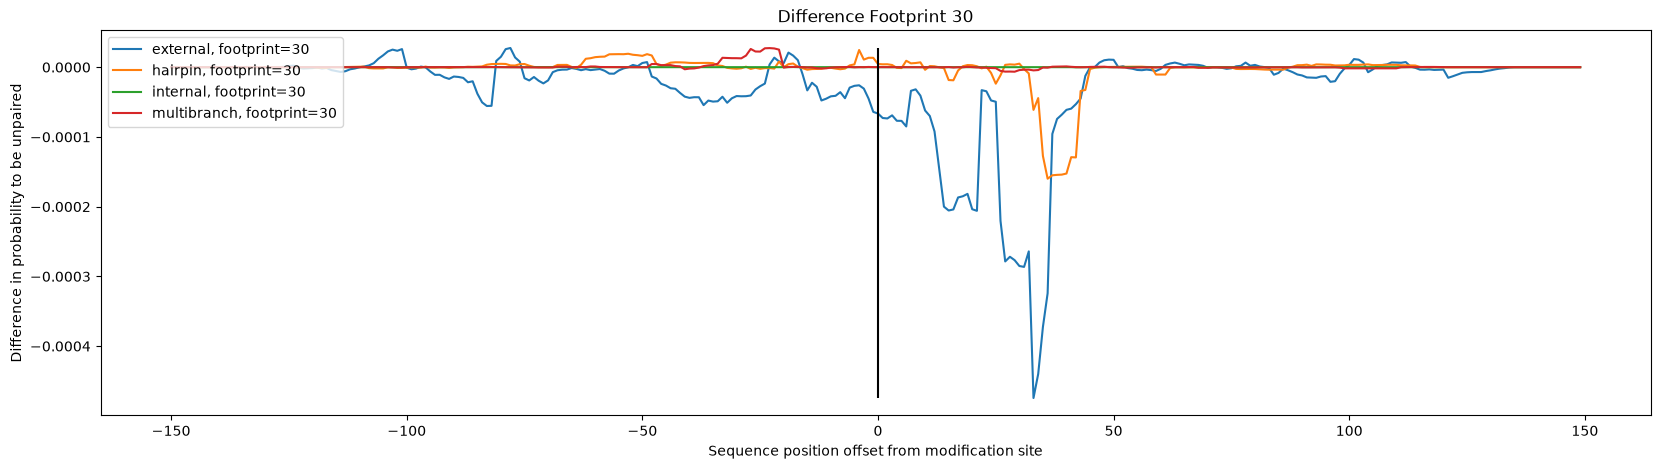

In [5]:
windowsize = 150

for footprint in average_diff_data:
    fig, axs = plt.subplots(figsize = (20, 5))

    min_value = 10
    max_value = -10
    for looptype, values in average_diff_data[footprint].items():
        half_length = int(len(values) / 2)
        values = values[half_length - windowsize:half_length + windowsize]
        half_length = int(len(values) / 2)
        min_value = min(min(values), min_value)
        max_value = max(max(values), max_value)
        axs.plot([i - half_length for i in range(len(values))], values, label = "{}, footprint={:d}".format(looptypes[looptype], footprint))
    axs.set_title("Difference Footprint " + str(footprint))
    axs.set_xlabel("Sequence position offset from modification site")
    axs.set_ylabel("Difference in probability to be unpaired")
    axs.vlines(0, min_value, max_value, 'k')
    axs.legend(loc="upper left")